# Mini-projeto 1 — Comparativo MLP (Fase 1) × CNN (Fase 2)

Este notebook **não treina nada**. Ele lê os `metadata.json` já salvos pelas
duas fases (`../../fase1-mlp/results/` e `../../fase2-cnn/results/`) e produz
as tabelas e gráficos que sustentam o [`README.md`](../README.md) desta pasta.

Rodar do zero leva segundos e não precisa de GPU.

In [1]:
#@title Setup e imports
import json, glob, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent.parent          # miniprojeto/
MLP_RESULTS = PROJECT_ROOT / "fase1-mlp" / "results"
CNN_RESULTS = PROJECT_ROOT / "fase2-cnn" / "results"
FIGURES = Path.cwd().parent / "figures"
FIGURES.mkdir(exist_ok=True)

CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]
VEHICLES = ["airplane", "automobile", "ship", "truck"]
ANIMALS  = ["bird", "cat", "deer", "dog", "frog", "horse"]

# Paleta consistente entre todos os graficos (uma cor por fase).
C_MLP, C_CNN, C_ACC, C_GREY = "#B5651D", "#2F6F9F", "#3E7C59", "#8A8A8A"
plt.rcParams.update({"figure.dpi": 130, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})

def load_runs(results_dir):
    """Carrega todos os metadata.json de uma pasta results/, indexados por run_name."""
    runs = {}
    for path in glob.glob(f"{results_dir}/*/metadata.json"):
        meta = json.load(open(path, encoding="utf-8"))
        name = meta.get("run_name") or os.path.basename(os.path.dirname(path))
        meta["_dir"] = os.path.dirname(path)
        runs[name] = meta
    return runs

mlp = load_runs(MLP_RESULTS)
cnn_all = load_runs(CNN_RESULTS)

# As tres redes do experimento hierarquico resolvem tarefas de 2, 4 e 6 classes -
# nao sao comparaveis com as de 10 classes e ficam fora de qualquer ranking.
HIER = {"hier_gate", "hier_vehicle", "hier_animal"}
cnn = {k: v for k, v in cnn_all.items() if k not in HIER}

print(f"MLP: {len(mlp)} execucoes | CNN: {len(cnn)} execucoes de 10 classes "
      f"(+{len(HIER)} do experimento hierarquico)")

MLP: 53 execucoes | CNN: 53 execucoes de 10 classes (+3 do experimento hierarquico)


## 1. O placar

Cada fase seguiu a mesma metodologia — busca gulosa por levas, cada uma
informada pela anterior, terminando num ensemble por soft voting sem retreino.
Isso torna os dois números diretamente comparáveis: mesmo dataset, mesma
divisão de validação, mesmo esforço de busca.

In [2]:
#@title Tabela do placar
def acc(runs, name):
    return runs[name]["metrics"]["test_accuracy"]

placar = pd.DataFrame([
    {"fase": "MLP (Fase 1)",  "etapa": "baseline",       "run": "best_combo",
     "acuracia": 0.5319},
    {"fase": "MLP (Fase 1)",  "etapa": "melhor unico",   "run": "augmentation_more_epochs",
     "acuracia": acc(mlp, "augmentation_more_epochs")},
    {"fase": "MLP (Fase 1)",  "etapa": "ensemble",       "run": "mlp_ensemble_final_softvote",
     "acuracia": acc(mlp, "mlp_ensemble_final_softvote")},
    {"fase": "CNN (Fase 2)",  "etapa": "baseline",       "run": "baseline",
     "acuracia": acc(cnn, "baseline")},
    {"fase": "CNN (Fase 2)",  "etapa": "melhor unico",   "run": "vgg4_mixcut_aug_ls",
     "acuracia": acc(cnn, "vgg4_mixcut_aug_ls")},
    {"fase": "CNN (Fase 2)",  "etapa": "ensemble",       "run": "ensemble_vgg4_all",
     "acuracia": acc(cnn, "ensemble_vgg4_all")},
])
placar["erro"] = 1 - placar["acuracia"]
placar

,fase,etapa,run,acuracia,erro
0,MLP (Fase 1),baseline,best_combo,0.5319,0.4681
1,MLP (Fase 1),melhor unico,augmentation_more_epochs,0.5998,0.4002
2,MLP (Fase 1),ensemble,mlp_ensemble_final_softvote,0.6135,0.3865
3,CNN (Fase 2),baseline,baseline,0.7148,0.2852
4,CNN (Fase 2),melhor unico,vgg4_mixcut_aug_ls,0.9490,0.0510
5,CNN (Fase 2),ensemble,ensemble_vgg4_all,0.9554,0.0446


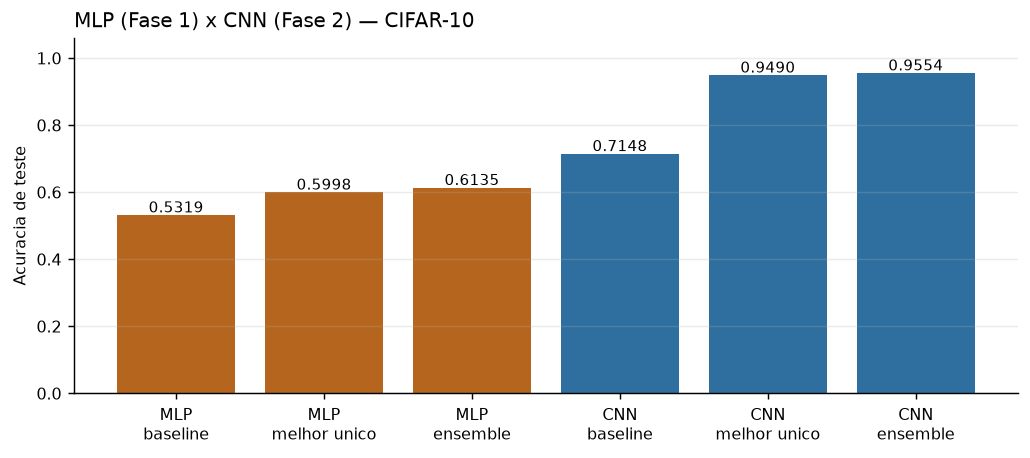

Ganho absoluto: +34.19 p.p.
Reducao da taxa de erro: 88.5%


In [3]:
#@title Grafico do placar
fig, ax = plt.subplots(figsize=(8, 3.6))
labels = [f"{r.fase.split()[0]}\n{r.etapa}" for r in placar.itertuples()]
colors = [C_MLP if "MLP" in f else C_CNN for f in placar["fase"]]
bars = ax.bar(labels, placar["acuracia"], color=colors)
for bar, v in zip(bars, placar["acuracia"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + .008, f"{v:.4f}", ha="center", fontsize=8.5)
ax.set_ylim(0, 1.06); ax.set_ylabel("Acuracia de teste"); ax.grid(axis="x", alpha=0)
ax.set_title("MLP (Fase 1) x CNN (Fase 2) — CIFAR-10", fontsize=11, loc="left")
fig.tight_layout(); fig.savefig(FIGURES / "mlp_vs_cnn_geral.png", bbox_inches="tight")
plt.show()

melhor_mlp, melhor_cnn = acc(mlp, "mlp_ensemble_final_softvote"), acc(cnn, "ensemble_vgg4_all")
print(f"Ganho absoluto: {(melhor_cnn - melhor_mlp)*100:+.2f} p.p.")
print(f"Reducao da taxa de erro: {(1 - (1-melhor_cnn)/(1-melhor_mlp))*100:.1f}%")

## 2. Onde a convolução fez diferença

O ganho não foi uniforme entre as classes — e a distribuição dele é a
evidência mais direta de *por que* a convolução ajuda. Se a CNN só fosse "uma
rede maior", o ganho seria parecido em todas as classes.

In [4]:
#@title Acuracia por classe: MLP x CNN
pc_mlp = mlp["mlp_ensemble_final_softvote"]["per_class_accuracy"]
pc_cnn = cnn["ensemble_vgg4_all"]["per_class_accuracy"]

por_classe = pd.DataFrame({
    "MLP (ensemble)": [pc_mlp[c] for c in CLASSES],
    "CNN (ensemble)": [pc_cnn[c] for c in CLASSES],
}, index=CLASSES)
por_classe["ganho (p.p.)"] = (por_classe["CNN (ensemble)"] - por_classe["MLP (ensemble)"]) * 100
por_classe["grupo"] = ["veiculo" if c in VEHICLES else "animal" for c in CLASSES]
por_classe.sort_values("ganho (p.p.)", ascending=False)

,MLP (ensemble),CNN (ensemble),ganho (p.p.),grupo
bird,0.429,0.937,50.8,animal
cat,0.421,0.893,47.2,animal
deer,0.500,0.969,46.9,animal
dog,0.495,0.915,42.0,animal
automobile,0.707,0.981,27.4,veiculo
horse,0.701,0.973,27.2,animal
airplane,0.696,0.967,27.1,veiculo
truck,0.710,0.969,25.9,veiculo
frog,0.738,0.975,23.7,animal
ship,0.738,0.975,23.7,veiculo


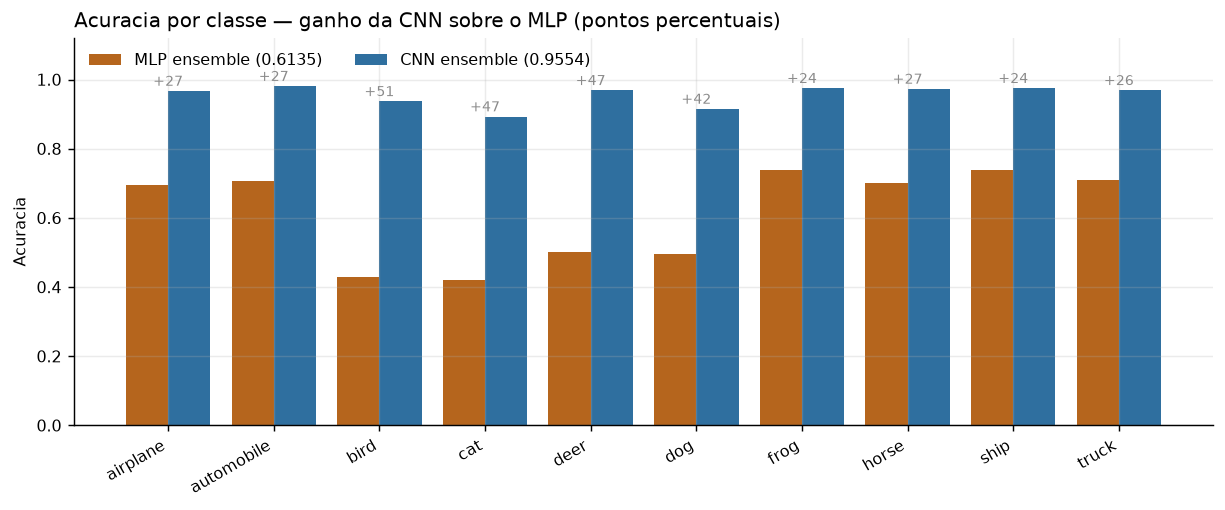

         MLP (ensemble)  CNN (ensemble)  ganho (p.p.)
grupo                                                
animal           0.5473          0.9437       39.6333
veiculo          0.7128          0.9730       26.0250


In [5]:
#@title Grafico por classe
x = np.arange(10)
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.bar(x - .2, [pc_mlp[c] for c in CLASSES], .4, label=f"MLP ensemble ({melhor_mlp:.4f})", color=C_MLP)
ax.bar(x + .2, [pc_cnn[c] for c in CLASSES], .4, label=f"CNN ensemble ({melhor_cnn:.4f})", color=C_CNN)
for i, c in enumerate(CLASSES):
    ax.text(i, max(pc_cnn[c], pc_mlp[c]) + .015, f"+{(pc_cnn[c]-pc_mlp[c])*100:.0f}",
            ha="center", fontsize=7.5, color=C_GREY)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha="right"); ax.set_ylim(0, 1.12)
ax.set_ylabel("Acuracia"); ax.legend(frameon=False, ncol=2, loc="upper left")
ax.set_title("Acuracia por classe — ganho da CNN sobre o MLP (pontos percentuais)",
             fontsize=11, loc="left")
fig.tight_layout(); fig.savefig(FIGURES / "per_class_mlp_vs_cnn.png", bbox_inches="tight")
plt.show()

print(por_classe.groupby("grupo")[["MLP (ensemble)", "CNN (ensemble)", "ganho (p.p.)"]].mean().round(4))

### A leitura

O ganho médio nos **animais** (+39,6 p.p.) é bem maior que o ganho nos
**veículos** (+26,0 p.p.). Não é coincidência: veículos têm silhueta rígida e
fundo consistente (céu, mar, asfalto), coisas que um MLP consegue capturar
mesmo achatando a imagem num vetor de 3072 valores. Animais dependem de
textura local e variam muito de pose — exatamente o que a convolução detecta
e o MLP não tem como representar.

`bird` (+50,8 p.p.), `cat` (+47,2 p.p.) e `deer` (+46,9 p.p.) foram as classes
mais beneficiadas — e eram justamente as três piores do MLP.

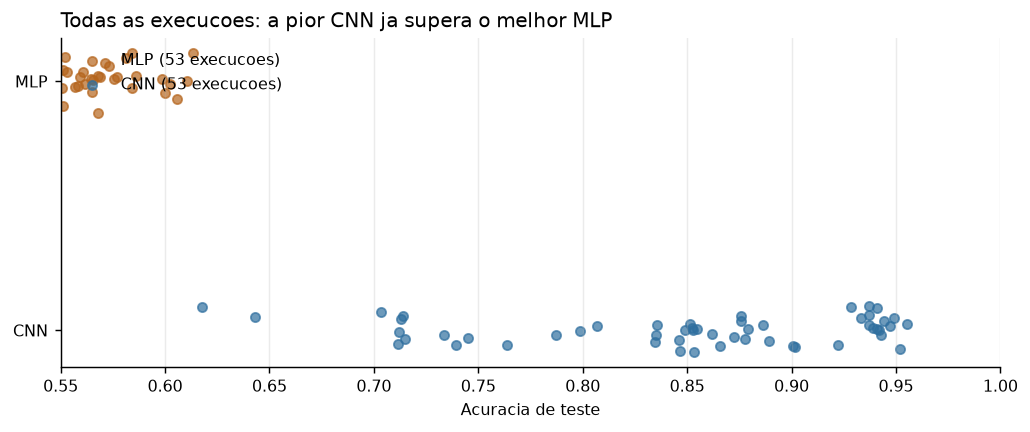

Pior CNN de todas: 0.6175  |  Melhor MLP de todos: 0.6135
A pior CNN supera o melhor MLP? True


In [6]:
#@title Distribuicao de todas as execucoes das duas fases
accs_mlp = [v["metrics"]["test_accuracy"] for v in mlp.values() if v["metrics"].get("test_accuracy")]
accs_cnn = [v["metrics"]["test_accuracy"] for v in cnn.values() if v["metrics"].get("test_accuracy")]

fig, ax = plt.subplots(figsize=(8, 3.4))
rng = np.random.RandomState(0)
ax.scatter(accs_mlp, rng.normal(1, .05, len(accs_mlp)), color=C_MLP, alpha=.7, s=26,
           label=f"MLP ({len(accs_mlp)} execucoes)")
ax.scatter(accs_cnn, rng.normal(0, .05, len(accs_cnn)), color=C_CNN, alpha=.7, s=26,
           label=f"CNN ({len(accs_cnn)} execucoes)")
ax.set_yticks([0, 1]); ax.set_yticklabels(["CNN", "MLP"]); ax.set_xlabel("Acuracia de teste")
ax.set_xlim(.55, 1.0); ax.legend(frameon=False, loc="upper left"); ax.grid(axis="y", alpha=0)
ax.set_title("Todas as execucoes: a pior CNN ja supera o melhor MLP", fontsize=11, loc="left")
fig.tight_layout(); fig.savefig(FIGURES / "distribuicao_execucoes.png", bbox_inches="tight")
plt.show()

print(f"Pior CNN de todas: {min(accs_cnn):.4f}  |  Melhor MLP de todos: {max(accs_mlp):.4f}")
print(f"A pior CNN supera o melhor MLP? {min(accs_cnn) > max(accs_mlp)}")

## 3. Custo: o que a CNN cobrou pelo ganho

Acurácia não é a única dimensão. A CNN é uma rede menor em número de
parâmetros, mas muito mais cara em tempo de treino, porque cada parâmetro
convolucional é reaplicado em todas as posições da imagem.

In [7]:
#@title Comparacao de custo
custo = pd.DataFrame([
    {"modelo": "MLP `augmentation_more_epochs`",
     "parametros": "~1,9 M",  "epocas": mlp["augmentation_more_epochs"]["metrics"]["epochs_trained"],
     "tempo aprox.": "~1 h (CPU)",   "acuracia": acc(mlp, "augmentation_more_epochs")},
    {"modelo": "CNN `vgg4_mixcut_aug_ls`",
     "parametros": "~4,8 M",  "epocas": cnn["vgg4_mixcut_aug_ls"]["metrics"]["epochs_trained"],
     "tempo aprox.": "~3-4 h (GPU)", "acuracia": acc(cnn, "vgg4_mixcut_aug_ls")},
])
custo

,modelo,parametros,epocas,tempo aprox.,acuracia
0,MLP `augmentation_more_epochs`,"~1,9 M",55,~1 h (CPU),0.5998
1,CNN `vgg4_mixcut_aug_ls`,"~4,8 M",200,~3-4 h (GPU),0.9490


## 4. O que as duas buscas ensinaram em comum

Rodar a mesma metodologia duas vezes, em duas famílias de modelo diferentes,
permite separar o que é lição sobre *o modelo* do que é lição sobre *como
buscar hiperparâmetros*. A célula abaixo resume as alavancas que se comportaram
igual e as que inverteram de sinal entre as fases.

In [8]:
#@title Alavancas: mesmo comportamento nas duas fases?
alavancas = pd.DataFrame([
    {"alavanca": "data augmentation (crop+flip)", "MLP": "ajudou muito", "CNN": "ajudou muito", "mesma direcao": True},
    {"alavanca": "color jitter",                  "MLP": "piorou",       "CNN": "piorou",       "mesma direcao": True},
    {"alavanca": "normalizacao real do CIFAR",    "MLP": "piorou",       "CNN": "piorou",       "mesma direcao": True},
    {"alavanca": "mais epocas apos augmentation", "MLP": "ajudou muito", "CNN": "ajudou muito", "mesma direcao": True},
    {"alavanca": "ensemble (soft voting)",        "MLP": "ajudou muito", "CNN": "ajudou muito", "mesma direcao": True},
    {"alavanca": "aumentar capacidade",           "MLP": "ajudou ate saturar", "CNN": "ajudou ate saturar", "mesma direcao": True},
    {"alavanca": "weight decay",                  "MLP": "melhor em zero",     "CNN": "melhor em 5e-4",     "mesma direcao": False},
    {"alavanca": "otimizador SGD vs Adam",        "MLP": "Adam melhor",        "CNN": "SGD melhor (+3 p.p.)", "mesma direcao": False},
    {"alavanca": "composicao do ensemble",        "MLP": "poucos e diversos",  "CNN": "todos os 7",          "mesma direcao": False},
])
alavancas

,alavanca,MLP,CNN,mesma direcao
0,data augmentation (crop+flip),ajudou muito,ajudou muito,True
1,color jitter,piorou,piorou,True
2,normalizacao real do CIFAR,piorou,piorou,True
3,mais epocas apos augmentation,ajudou muito,ajudou muito,True
4,ensemble (soft voting),ajudou muito,ajudou muito,True
5,aumentar capacidade,ajudou ate saturar,ajudou ate saturar,True
6,weight decay,melhor em zero,melhor em 5e-4,False
7,otimizador SGD vs Adam,Adam melhor,SGD melhor (+3 p.p.),False
8,composicao do ensemble,poucos e diversos,todos os 7,False


### Seis alavancas se comportaram igual, três inverteram

As que **se repetiram** dizem respeito ao problema, não à arquitetura:
augmentation geométrica ajuda, augmentation de cor atrapalha, normalização
"estatisticamente correta" não ajuda quando há batch norm, modelos precisam de
mais épocas depois que se adiciona augmentation, e ensemble sempre rende.

As que **inverteram** dizem respeito à família de modelo. O weight decay foi
melhor em zero no MLP e em 5e-4 na CNN. O Adam venceu no MLP e perdeu por
~3 p.p. para SGD+momentum na CNN — diferença que só aparece quando a rede fica
funda. E a composição do ensemble: no MLP, adicionar membros correlacionados
piorava; na CNN, usar os 7 modelos bateu usar os 3 melhores, porque cada um
tinha sido treinado com um regularizador diferente.

A lição transversal, que apareceu nas duas fases: **quando a busca satura,
o ganho vem de trocar a categoria de alavanca, não de ajustar melhor a que já
se estava usando.** No MLP isso foi augmentation e schedule (rodada 6); na
CNN, a arquitetura VGG (leva 6) e depois MixUp/CutMix (leva 8).

## 5. O limite de cada família

O MLP parou em 0.6135 por uma razão estrutural: achatar a imagem 32×32×3 num
vetor de 3072 valores destrói a estrutura espacial. Não há invariância
translacional nem detecção de padrões locais, e nenhuma alavanca de
hiperparâmetro recupera isso — só mitiga sintomas.

A CNN chegou a 0.9554 e parou por outra razão: o par `cat`/`dog` responde por
43% dos erros restantes. Não é limitação da convolução, é a dificuldade
intrínseca de distinguir dois animais peludos de quatro patas em 32×32 pixels.

A célula abaixo quantifica quanto do erro de cada fase está concentrado nessas
duas classes.

In [9]:
#@title Concentracao do erro nas classes dificeis
def erros_por_classe(pc, n_por_classe=1000):
    return {c: round((1 - pc[c]) * n_por_classe) for c in CLASSES}

for nome, pc in [("MLP (ensemble)", pc_mlp), ("CNN (ensemble)", pc_cnn)]:
    e = erros_por_classe(pc); total = sum(e.values())
    dificeis = e["cat"] + e["dog"]
    print(f"{nome}: {total} erros | cat+dog = {dificeis} ({dificeis/total*100:.1f}% do erro total)")
    print("   piores classes:", sorted(e.items(), key=lambda kv: -kv[1])[:3])

MLP (ensemble): 3865 erros | cat+dog = 1084 (28.0% do erro total)
   piores classes: [('cat', 579), ('bird', 571), ('dog', 505)]
CNN (ensemble): 446 erros | cat+dog = 192 (43.0% do erro total)
   piores classes: [('cat', 107), ('dog', 85), ('bird', 63)]


## 6. Conclusão

A convolução valeu **+34,2 pontos percentuais** sobre a melhor configuração de
MLP encontrada com esforço de busca equivalente — uma redução de 88,5% na taxa
de erro (de 38,7% para 4,5%). O ganho concentrou-se exatamente onde a teoria previa: nas classes
que dependem de textura e pose em vez de silhueta global.

Mas o ganho não veio "de graça" por trocar de arquitetura. A CNN baseline
(0.7148) já superava qualquer MLP, e ainda assim foram necessárias **oito
levas de busca** para chegar a 0.9554. A arquitetura abriu o teto; a busca de
hiperparâmetros foi o que preencheu os 24 pontos percentuais entre o baseline
convolucional e o resultado final.

Análise completa em [`../README.md`](../README.md).